# MediaPipe Hand Landmarker - Reference Notebook

This notebook demonstrates how to use the MediaPipe Hand Landmarker Tasks API to extract 21 hand landmarks from images.

**References:**
- [Hand Landmarker docs](https://ai.google.dev/edge/mediapipe/solutions/vision/hand_landmarker)
- [Python guide](https://ai.google.dev/edge/mediapipe/solutions/vision/hand_landmarker/python)
- [Official notebook](https://colab.research.google.com/github/googlesamples/mediapipe/blob/main/examples/hand_landmarker/python/hand_landmarker.ipynb)

## 1. Imports

In [1]:
import mediapipe as mp
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

## 2. Setup the Hand Landmarker

Make sure you have the model file at `models/hand_landmarker.task`.

Download it with:
```bash
curl -o models/hand_landmarker.task https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/latest/hand_landmarker.task
```

In [2]:
MODEL_PATH = "../models/hand_landmarker.task"

base_options = python.BaseOptions(model_asset_path=MODEL_PATH)
options = vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=1,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5,
)

print("Hand Landmarker configured successfully")

Hand Landmarker configured successfully


## 3. Load and Process an Image

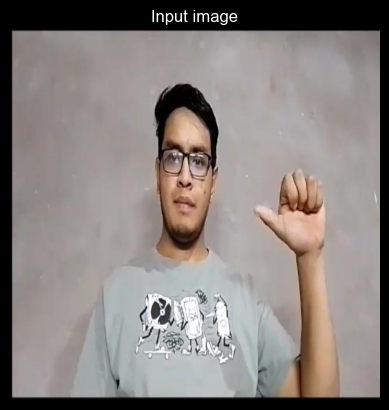

Image size: 640x640


In [3]:
IMAGE_PATH = "hand.jpg"  # change to any image in your dataset

# Load with MediaPipe
mp_image = mp.Image.create_from_file(IMAGE_PATH)

# Show the image
img_bgr = cv2.imread(IMAGE_PATH)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Input image")
plt.show()

print(f"Image size: {mp_image.width}x{mp_image.height}")

## 4. Run Detection

In [4]:
with vision.HandLandmarker.create_from_options(options) as landmarker:
    result = landmarker.detect(mp_image)

if result.hand_landmarks:
    print(result)
    print(f"Hands detected: {len(result.hand_landmarks)}")
    print(f"Handedness: {result.handedness[0][0].display_name}")
else:
    print("No hand detected")

I0000 00:00:1779081501.856397 23574618 init-domain.cc:128] Fiber init: default domain = pthread, concurrency = 15, prefix = pthread-default
I0000 00:00:1779081501.947879 23574618 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M4 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1779081501.956613 23574620 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779081501.966618 23574627 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779081501.980394 23574628 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


HandLandmarkerResult(handedness=[[Category(index=1, score=0.9760434031486511, display_name='Left', category_name='Left')]], hand_landmarks=[[NormalizedLandmark(x=0.8147205710411072, y=0.5799782872200012, z=-1.4353459221183584e-07, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.7634332776069641, y=0.5693577527999878, z=-0.025998186320066452, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.7258259057998657, y=0.534498929977417, z=-0.04196736216545105, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.6966994404792786, y=0.5029568076133728, z=-0.056830089539289474, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.6680217981338501, y=0.4815807342529297, z=-0.06727864593267441, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.746084451675415, y=0.45728600025177, z=-0.01770448125898838, visibility=None, presence=None, name=None), NormalizedLandmark(x=0.7539907693862915, y=0.4122149348258972, z=-0.0436

## 5. Inspect the 21 Landmarks

In [5]:
LANDMARK_NAMES = [
    "WRIST",
    "THUMB_CMC", "THUMB_MCP", "THUMB_IP", "THUMB_TIP",
    "INDEX_MCP", "INDEX_PIP", "INDEX_DIP", "INDEX_TIP",
    "MIDDLE_MCP", "MIDDLE_PIP", "MIDDLE_DIP", "MIDDLE_TIP",
    "RING_MCP", "RING_PIP", "RING_DIP", "RING_TIP",
    "PINKY_MCP", "PINKY_PIP", "PINKY_DIP", "PINKY_TIP",
]

if result.hand_landmarks:
    landmarks = result.hand_landmarks[0]
    for i, lm in enumerate(landmarks):
        print(f"[{i:2d}] {LANDMARK_NAMES[i]:15s} x={lm.x:.4f}  y={lm.y:.4f}  z={lm.z:.4f}")

[ 0] WRIST           x=0.8147  y=0.5800  z=-0.0000
[ 1] THUMB_CMC       x=0.7634  y=0.5694  z=-0.0260
[ 2] THUMB_MCP       x=0.7258  y=0.5345  z=-0.0420
[ 3] THUMB_IP        x=0.6967  y=0.5030  z=-0.0568
[ 4] THUMB_TIP       x=0.6680  y=0.4816  z=-0.0673
[ 5] INDEX_MCP       x=0.7461  y=0.4573  z=-0.0177
[ 6] INDEX_PIP       x=0.7540  y=0.4122  z=-0.0437
[ 7] INDEX_DIP       x=0.7625  y=0.4480  z=-0.0558
[ 8] INDEX_TIP       x=0.7618  y=0.4779  z=-0.0585
[ 9] MIDDLE_MCP      x=0.7782  y=0.4543  z=-0.0155
[10] MIDDLE_PIP      x=0.7855  y=0.4097  z=-0.0420
[11] MIDDLE_DIP      x=0.7907  y=0.4542  z=-0.0491
[12] MIDDLE_TIP      x=0.7878  y=0.4814  z=-0.0466
[13] RING_MCP        x=0.8094  y=0.4567  z=-0.0178
[14] RING_PIP        x=0.8159  y=0.4183  z=-0.0410
[15] RING_DIP        x=0.8147  y=0.4588  z=-0.0368
[16] RING_TIP        x=0.8078  y=0.4848  z=-0.0272
[17] PINKY_MCP       x=0.8370  y=0.4636  z=-0.0227
[18] PINKY_PIP       x=0.8420  y=0.4373  z=-0.0377
[19] PINKY_DIP       x=0.8369  

## 6. Visualize Landmarks on the Image

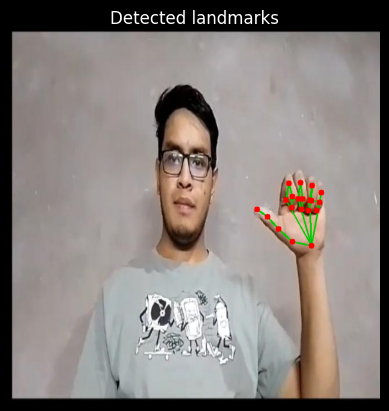

In [7]:
def draw_landmarks(image, detection_result):
    annotated = np.copy(image)
    h, w, _ = annotated.shape

    # Connections between landmarks (MediaPipe hand topology)
    connections = [
        (0,1),(1,2),(2,3),(3,4),           # thumb
        (0,5),(5,6),(6,7),(7,8),           # index
        (0,9),(9,10),(10,11),(11,12),      # middle
        (0,13),(13,14),(14,15),(15,16),    # ring
        (0,17),(17,18),(18,19),(19,20),    # pinky
        (5,9),(9,13),(13,17),              # palm
    ]

    for hand_landmarks in detection_result.hand_landmarks:
        # Draw connections
        for start, end in connections:
            x0 = int(hand_landmarks[start].x * w)
            y0 = int(hand_landmarks[start].y * h)
            x1 = int(hand_landmarks[end].x * w)
            y1 = int(hand_landmarks[end].y * h)
            cv2.line(annotated, (x0, y0), (x1, y1), (0, 200, 0), 2)

        # Draw points
        for lm in hand_landmarks:
            x = int(lm.x * w)
            y = int(lm.y * h)
            cv2.circle(annotated, (x, y), 5, (255, 0, 0), -1)

    return annotated

annotated_image = draw_landmarks(img_rgb, result)
plt.imshow(annotated_image)
plt.axis("off")
plt.title("Detected landmarks")
plt.show()

## 7. Extract Raw Keypoints (what goes into the model)

In [8]:
def extract_keypoints(detection_result):
    """Returns a flat list of 21 points: [[x,y,z], [x,y,z], ...]"""
    if not detection_result.hand_landmarks:
        return None
    landmarks = detection_result.hand_landmarks[0]
    return [[lm.x, lm.y, lm.z] for lm in landmarks]

keypoints = extract_keypoints(result)

if keypoints:
    import json
    print(f"Shape: {len(keypoints)} points x {len(keypoints[0])} coords")
    print(f"\nRaw keypoints:")
    print(json.dumps(keypoints, indent=2))

Shape: 21 points x 3 coords

Raw keypoints:
[
  [
    0.8147205710411072,
    0.5799782872200012,
    -1.4353459221183584e-07
  ],
  [
    0.7634332776069641,
    0.5693577527999878,
    -0.025998186320066452
  ],
  [
    0.7258259057998657,
    0.534498929977417,
    -0.04196736216545105
  ],
  [
    0.6966994404792786,
    0.5029568076133728,
    -0.056830089539289474
  ],
  [
    0.6680217981338501,
    0.4815807342529297,
    -0.06727864593267441
  ],
  [
    0.746084451675415,
    0.45728600025177,
    -0.01770448125898838
  ],
  [
    0.7539907693862915,
    0.4122149348258972,
    -0.04367487505078316
  ],
  [
    0.7625247836112976,
    0.4480026960372925,
    -0.05583549290895462
  ],
  [
    0.7618141174316406,
    0.47785282135009766,
    -0.05847273766994476
  ],
  [
    0.7782391309738159,
    0.45432403683662415,
    -0.01554839126765728
  ],
  [
    0.7855497002601624,
    0.40971362590789795,
    -0.041951846331357956
  ],
  [
    0.7906582355499268,
    0.4542203545570